In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("../dataimport/train.csv")
valid = pd.read_csv("../dataimport/valid.csv")
test = pd.read_csv("../dataimport/test.csv")

print("Train :", train.shape)
print("Valid :", valid.shape)
print("Test  :", test.shape)

Train : (10240, 14)
Valid : (1284, 14)
Test  : (1267, 14)


label
half-true      20.644531
false          19.482422
mostly-true    19.160156
true           16.367188
barely-true    16.152344
pants-fire      8.193359
Name: proportion, dtype: float64


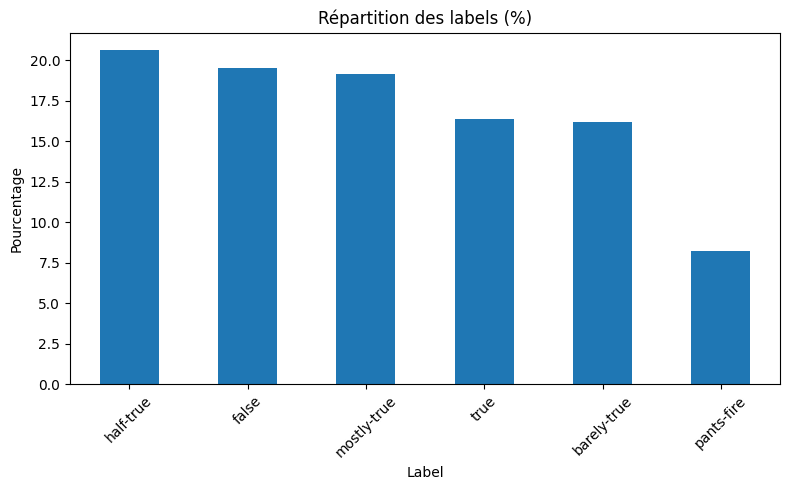

In [3]:
label_pct = train["label"].value_counts(normalize=True) * 100
print(label_pct)

plt.figure(figsize=(8,5))
label_pct.sort_values(ascending=False).plot(kind="bar")
plt.title("Répartition des labels (%)")
plt.xlabel("Label")
plt.ylabel("Pourcentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

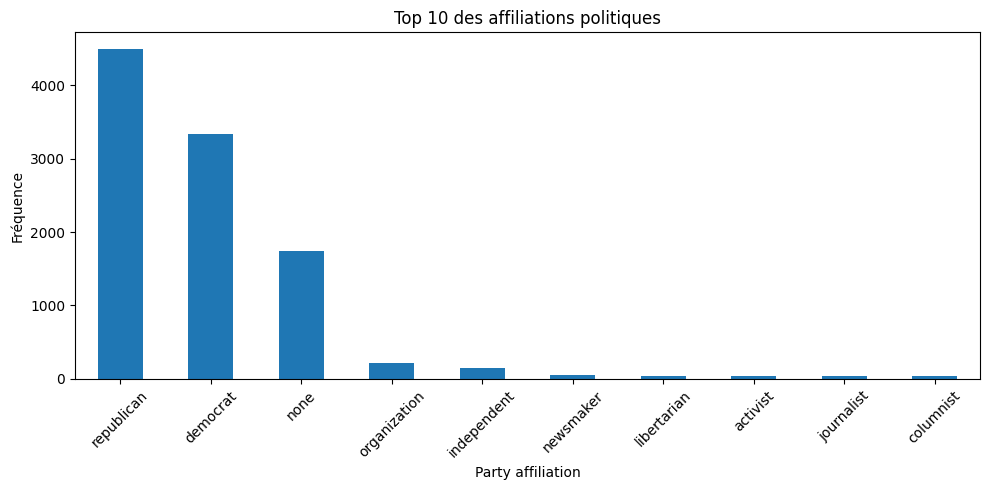

In [4]:
plt.figure(figsize=(10,5))
train["party_affiliation"].fillna("unknown").value_counts().head(10).plot(kind="bar")
plt.title("Top 10 des affiliations politiques")
plt.xlabel("Party affiliation")
plt.ylabel("Fréquence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

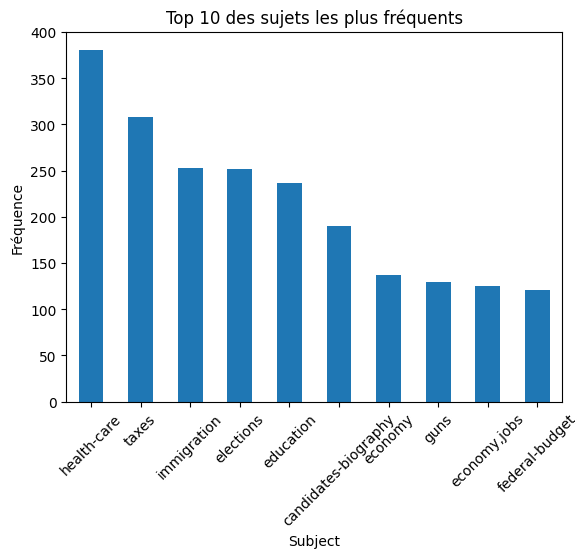

In [5]:
train["subject"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 des sujets les plus fréquents")
plt.xlabel("Subject")
plt.ylabel("Fréquence")
plt.xticks(rotation=45)
plt.show()

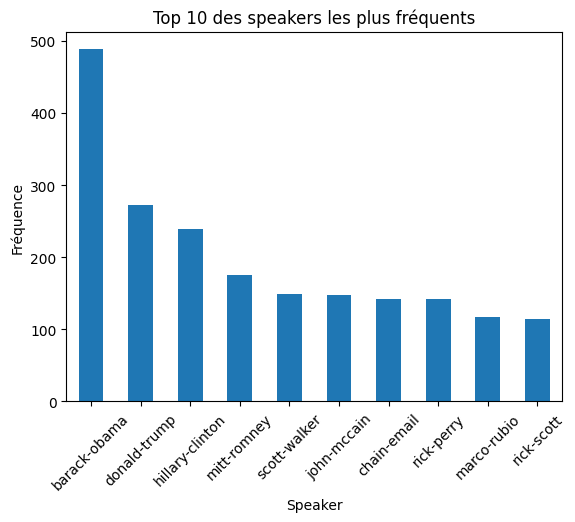

In [6]:
train["speaker"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 des speakers les plus fréquents")
plt.xlabel("Speaker")
plt.ylabel("Fréquence")
plt.xticks(rotation=45)
plt.show()

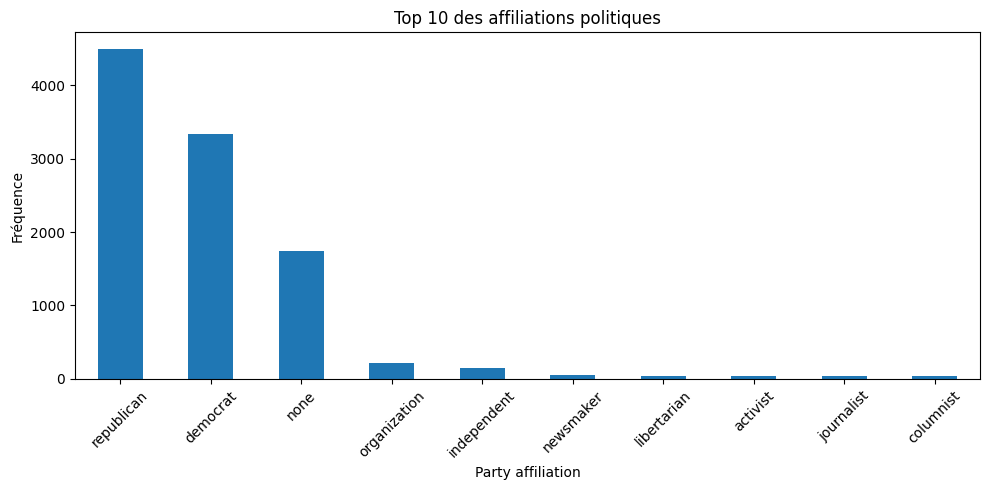

In [7]:
plt.figure(figsize=(10,5))
train["party_affiliation"].fillna("unknown").value_counts().head(10).plot(kind="bar")
plt.title("Top 10 des affiliations politiques")
plt.xlabel("Party affiliation")
plt.ylabel("Fréquence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
top_speakers = train["speaker"].value_counts().head(10).index
subset = train[train["speaker"].isin(top_speakers)]

pd.crosstab(subset["speaker"], subset["label"])

label,barely-true,false,half-true,mostly-true,pants-fire,true
speaker,,,,,,
barack-obama,56,67,124,130,8,103
chain-email,9,34,8,5,82,4
donald-trump,48,101,39,27,52,6
hillary-clinton,30,27,51,65,6,60
john-mccain,24,33,26,30,6,29
marco-rubio,26,21,28,24,2,16
mitt-romney,27,28,47,27,17,30
rick-perry,23,29,36,17,16,21
rick-scott,18,19,30,28,7,13


In [9]:
cat_cols = ["label", "subject", "speaker", "party_affiliation", "state_info", "context"]

for col in cat_cols:
    if col in train.columns:
        print(f"{col} : {train[col].nunique()} valeurs uniques")

label : 6 valeurs uniques
subject : 3827 valeurs uniques
speaker : 2910 valeurs uniques
party_affiliation : 23 valeurs uniques
state_info : 83 valeurs uniques
context : 4345 valeurs uniques


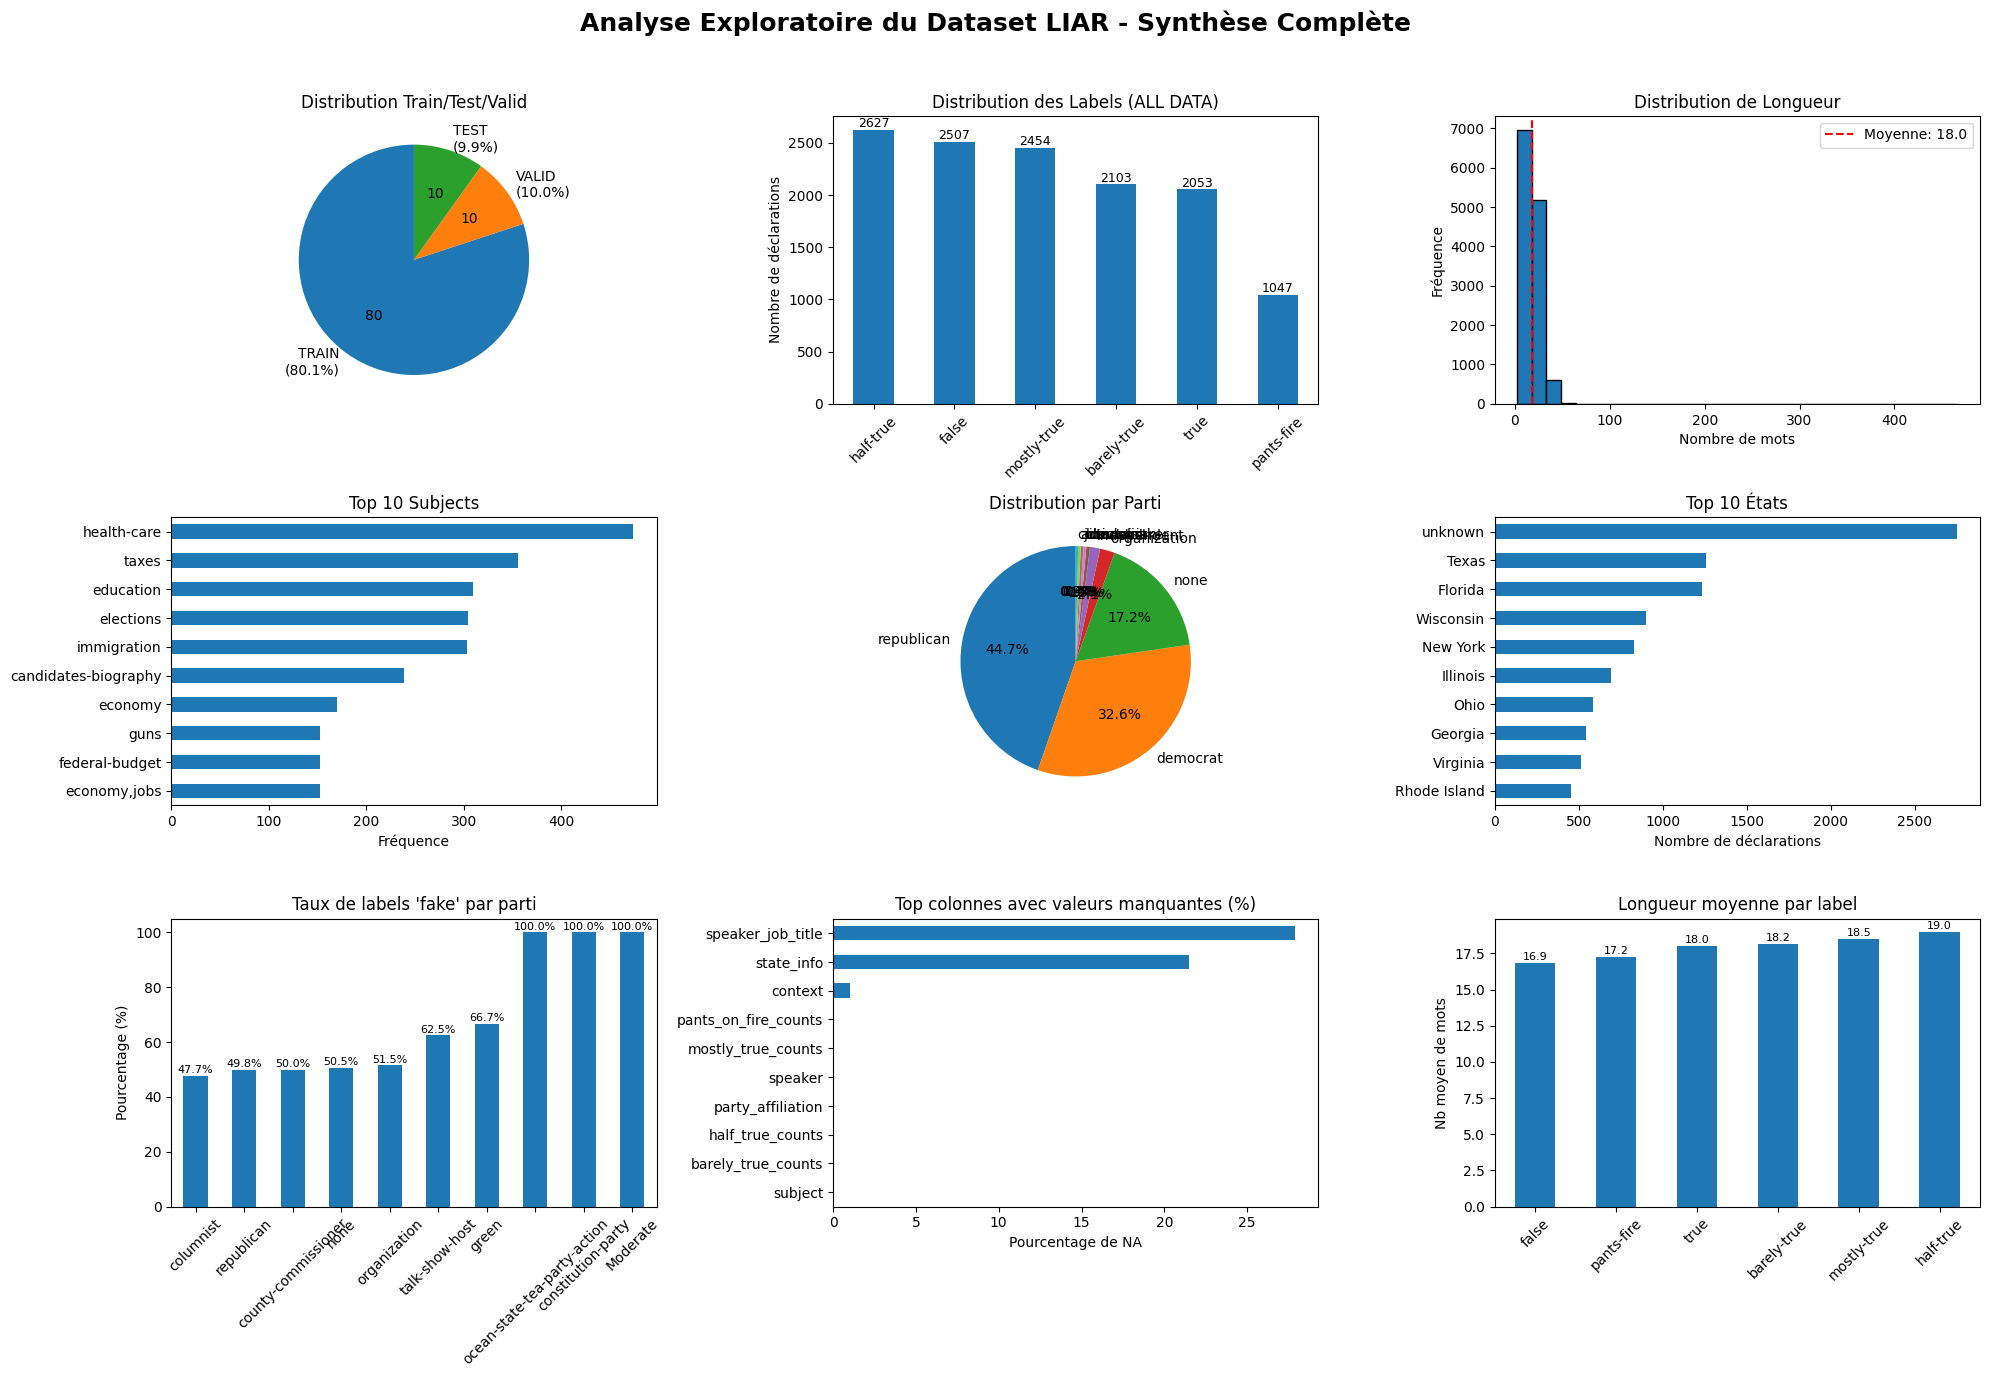

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Préparation des données
# =========================

# Copie pour éviter de modifier tes dataframes d'origine
train_df = train.copy()
valid_df = valid.copy()
test_df = test.copy()

# Ajout d'une colonne split
train_df["split"] = "TRAIN"
valid_df["split"] = "VALID"
test_df["split"] = "TEST"

# Concaténation pour certaines stats globales
all_data = pd.concat([train_df, valid_df, test_df], ignore_index=True)

# Longueur des statements
for df in [train_df, valid_df, test_df, all_data]:
    df["statement_len_words"] = df["statement"].astype(str).apply(lambda x: len(x.split()))

# =========================
# 2) Stats utiles
# =========================

# Répartition train/valid/test
split_counts = all_data["split"].value_counts()

# Distribution des labels
label_counts = all_data["label"].value_counts()

# Longueur des statements
lengths = all_data["statement_len_words"]
mean_length = lengths.mean()

# Top subjects
subject_counts = all_data["subject"].fillna("unknown").value_counts().head(10)

# Répartition par parti
party_counts = all_data["party_affiliation"].fillna("unknown").value_counts().head(10)

# Top états
state_counts = all_data["state_info"].fillna("unknown").value_counts().head(10)

# Valeurs manquantes (%)
missing_pct = (all_data.isna().sum() / len(all_data) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0].head(10)

# Taux de "mensonge" par parti (approximation multiclasse)
# fake = pants-fire, false, barely-true
fake_labels = ["pants-fire", "false", "barely-true"]
party_fake_rate = (
    all_data.assign(is_fake=all_data["label"].isin(fake_labels).astype(int))
            .groupby("party_affiliation")["is_fake"]
            .mean()
            .sort_values(ascending=False) * 100
)
party_fake_rate = party_fake_rate.head(10)

# =========================
# 3) Figure synthèse
# =========================

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle("Analyse Exploratoire du Dataset LIAR - Synthèse Complète", fontsize=18, fontweight="bold")

# ---- (1) Pie chart Train/Valid/Test
axes[0, 0].pie(
    split_counts.values,
    labels=[f"{k}\n({v/len(all_data)*100:.1f}%)" for k, v in split_counts.items()],
    autopct="%1.0f",
    startangle=90
)
axes[0, 0].set_title("Distribution Train/Test/Valid")

# ---- (2) Distribution des labels
label_counts.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Distribution des Labels (ALL DATA)")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Nombre de déclarations")
axes[0, 1].tick_params(axis="x", rotation=45)

for i, v in enumerate(label_counts.values):
    axes[0, 1].text(i, v + max(label_counts.values)*0.01, str(v), ha="center", fontsize=9)

# ---- (3) Histogramme longueurs
axes[0, 2].hist(lengths, bins=30, edgecolor="black")
axes[0, 2].axvline(mean_length, color="red", linestyle="--", label=f"Moyenne: {mean_length:.1f}")
axes[0, 2].set_title("Distribution de Longueur")
axes[0, 2].set_xlabel("Nombre de mots")
axes[0, 2].set_ylabel("Fréquence")
axes[0, 2].legend()

# ---- (4) Top subjects
subject_counts.sort_values().plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Top 10 Subjects")
axes[1, 0].set_xlabel("Fréquence")
axes[1, 0].set_ylabel("")

# ---- (5) Répartition par parti
axes[1, 1].pie(
    party_counts.values,
    labels=party_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1, 1].set_title("Distribution par Parti")

# ---- (6) Top états
state_counts.sort_values().plot(kind="barh", ax=axes[1, 2])
axes[1, 2].set_title("Top 10 États")
axes[1, 2].set_xlabel("Nombre de déclarations")
axes[1, 2].set_ylabel("")

# ---- (7) Taux de fake par parti
party_fake_rate.sort_values().plot(kind="bar", ax=axes[2, 0])
axes[2, 0].set_title("Taux de labels 'fake' par parti")
axes[2, 0].set_xlabel("")
axes[2, 0].set_ylabel("Pourcentage (%)")
axes[2, 0].tick_params(axis="x", rotation=45)

for i, v in enumerate(party_fake_rate.sort_values().values):
    axes[2, 0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=8)

# ---- (8) Valeurs manquantes
if len(missing_pct) > 0:
    missing_pct.sort_values().plot(kind="barh", ax=axes[2, 1])
    axes[2, 1].set_title("Top colonnes avec valeurs manquantes (%)")
    axes[2, 1].set_xlabel("Pourcentage de NA")
    axes[2, 1].set_ylabel("")
else:
    axes[2, 1].text(0.5, 0.5, "Aucune valeur manquante", ha="center", va="center", fontsize=12)
    axes[2, 1].set_title("Valeurs manquantes")
    axes[2, 1].axis("off")

# ---- (9) Longueur moyenne par label
mean_len_by_label = all_data.groupby("label")["statement_len_words"].mean().sort_values()
mean_len_by_label.plot(kind="bar", ax=axes[2, 2])
axes[2, 2].set_title("Longueur moyenne par label")
axes[2, 2].set_xlabel("")
axes[2, 2].set_ylabel("Nb moyen de mots")
axes[2, 2].tick_params(axis="x", rotation=45)

for i, v in enumerate(mean_len_by_label.values):
    axes[2, 2].text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()